This notebook processes the outputs of brute_force_mixing.py for experiment names "full_aug" and "partial_aug". In contrast to the partial base group notebook, the base group is not sampled for these experiments and the augmentation group is not necessarily the same size as the base group.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
import pickle

In [2]:
# Load mixing ratios and metrics
exp_name = "full_aug"
filename = f"../results/mixing_results_by_group_{exp_name}.pickle"
with open(filename, "rb") as pickleFile:
    mixing_results_by_group = pickle.load(pickleFile)

for label in mixing_results_by_group:
    assert len(mixing_results_by_group[label]["validation ps"]) == len(mixing_results_by_group[label]["validation metrics"])
    print(f"{label}: {len(mixing_results_by_group[label]['validation ps'])} trials")
    
    ps = mixing_results_by_group[label]["validation ps"]
    group_labels = set(ps[0].keys())
    assert np.all([group_labels == set(p.keys()) for p in ps])
    
    metric_dicts = mixing_results_by_group[label]["validation metrics"]
    metric_names = set(metric_dicts[0].keys())
    assert np.all([metric_names == set(metric_dict.keys()) for metric_dict in metric_dicts])

1: 2000 trials
18: 2000 trials
25: 2000 trials
35: 2000 trials
45: 2000 trials
50: 2000 trials
56: 2000 trials


## Analyzing Best Mixing Ratios

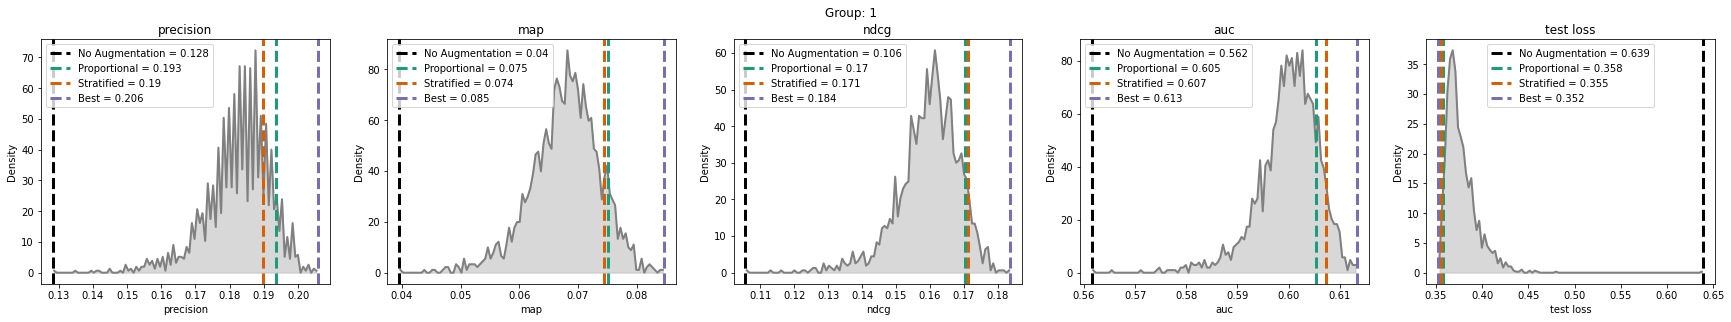

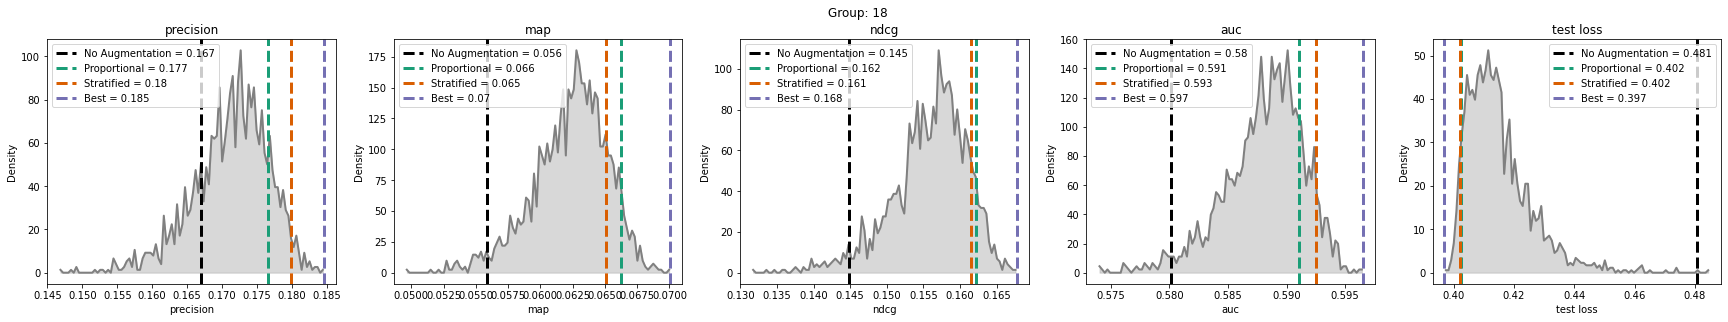

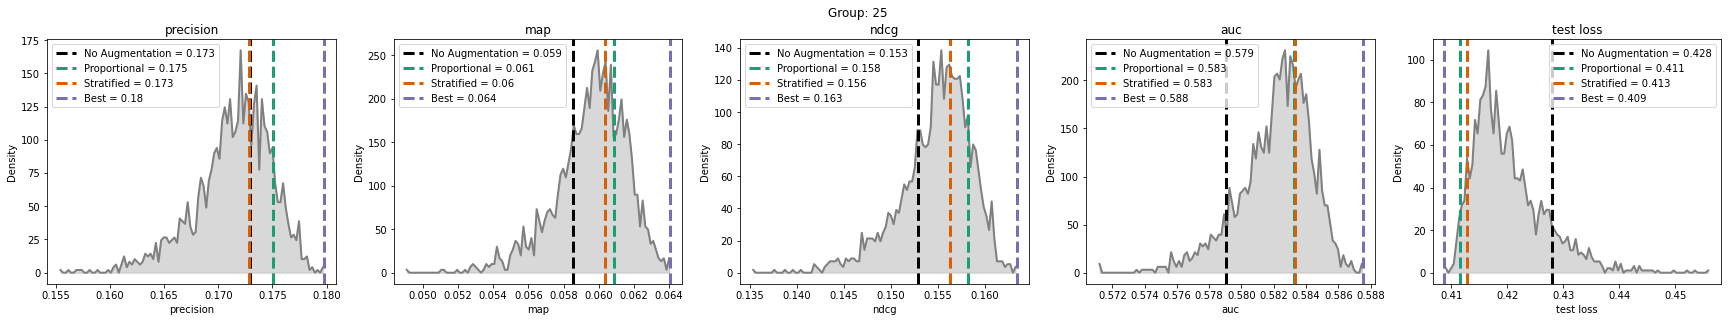

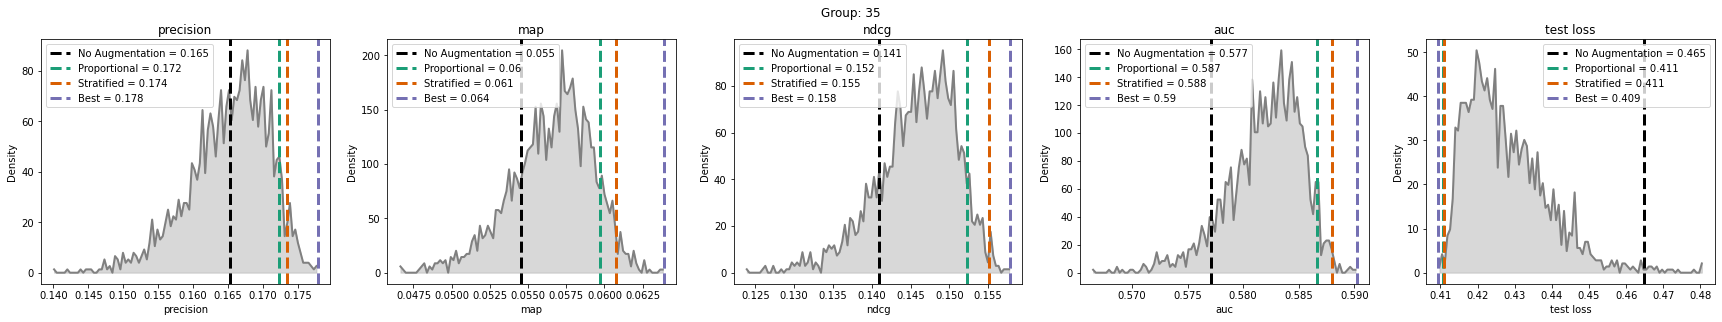

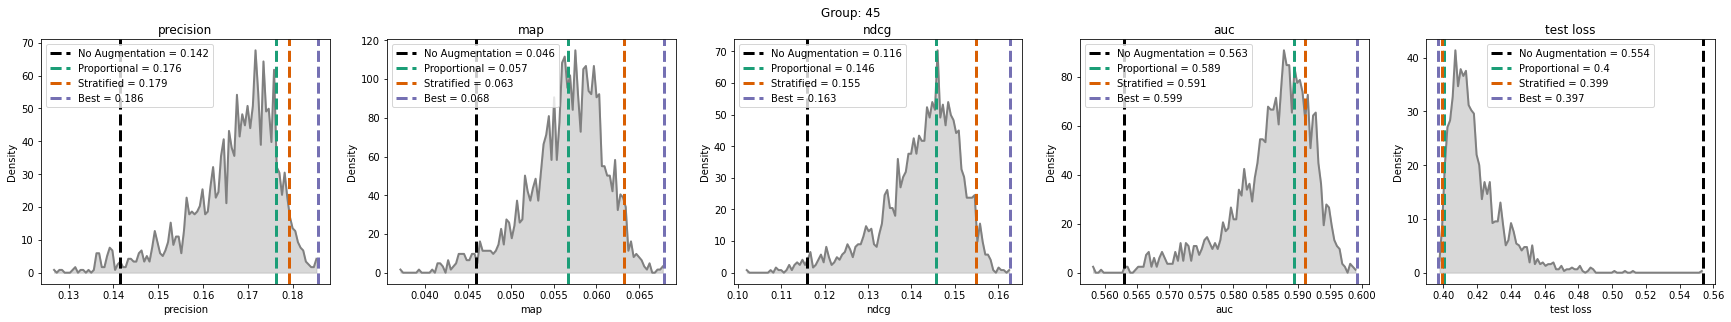

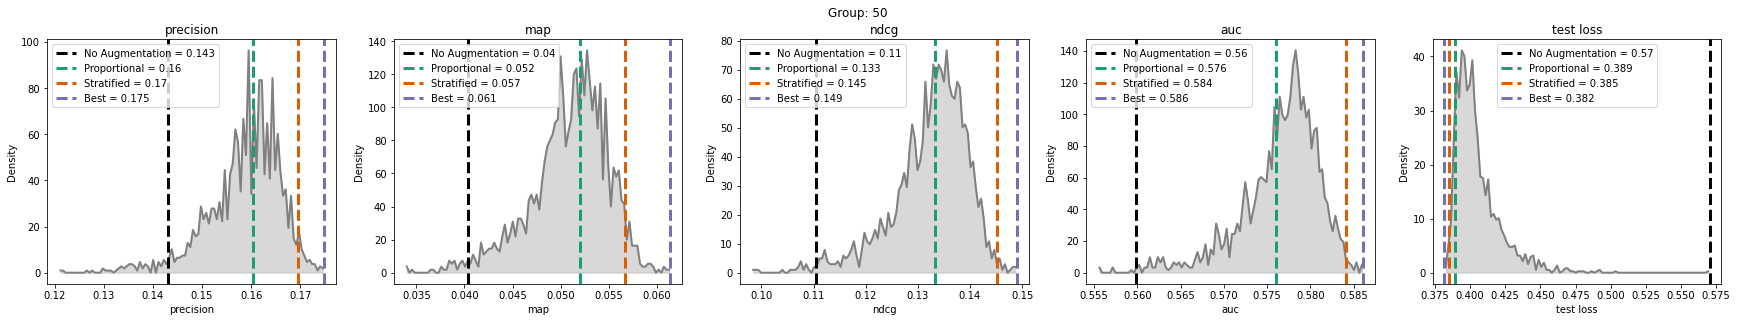

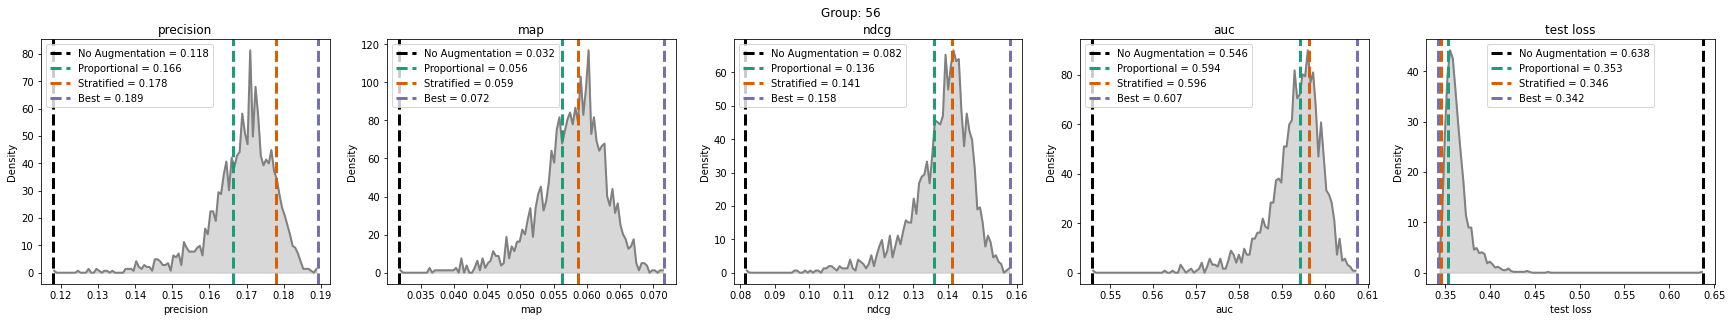

In [3]:
colors = ["black", "#1b9e77", "#d95f02", "#7570b3"]
def plot_density_with_baseline(values, baseline_tuples, value_name="Values", title="Density Plot", ax=None):
    """
    Pure Matplotlib density plot with a vertical dashed baseline line.
    """
    values = np.asarray(values)

    # Compute histogram-based density estimate
    density, bins = np.histogram(values, bins=100, density=True)
    centers = 0.5 * (bins[:-1] + bins[1:])

    if ax == None:
        fig, ax = plt.subplots()

    ax.plot(centers, density, linewidth=2, color="gray")
    ax.fill_between(centers, density, alpha=0.3, color="gray")

    for baseline_idx, (baseline_name, baseline_val) in enumerate(baseline_tuples):
        ax.axvline(baseline_val, 
                   color=colors[baseline_idx],
                   linestyle="--", linewidth=3, 
                   label=f"{baseline_name} = {round(baseline_val, 3)}")

    ax.set_title(title)
    ax.set_xlabel(value_name)
    ax.set_ylabel("Density")
    ax.legend()

for label in mixing_results_by_group:
    metric_names = list(mixing_results_by_group[label]["validation metrics"][0].keys())
    metric_dicts = mixing_results_by_group[label]["validation metrics"]
    
    fig, axs = plt.subplots(ncols=len(metric_names), figsize=(6*len(metric_names), 4.5))
    fig.suptitle(f"Group: {label}")
    for metric_idx, metric_name in enumerate(metric_names):
        metric_vals = [metric_dict[metric_name] for metric_dict in metric_dicts]
        plot_density_with_baseline(metric_vals,
                                  baseline_tuples=[
                                      ("No Augmentation", metric_vals[0]), 
                                      ("Proportional", metric_vals[1]),
                                      ("Stratified", metric_vals[2]),
                                      ("Best", np.min(metric_vals) if "loss" in metric_name else np.max(metric_vals))
                                  ],
                                  value_name=metric_name,
                                  title=metric_name,
                                  ax=axs[metric_idx])


In [4]:
## merge in the test metrics for the best partial augmentation
exp_name = "partial_aug"
filename = f"../results/mixing_results_by_group_{exp_name}.pickle"
with open(filename, "rb") as pickleFile:
    mixing_results_by_group_partial_aug = pickle.load(pickleFile)
    
for label in mixing_results_by_group:
    mixing_results_by_group[label]["test metrics"].append(
        mixing_results_by_group_partial_aug[label]["test metrics"][-1]
    )
    mixing_results_by_group[label]["test metrics"].append(
        mixing_results_by_group_partial_aug[label]["test metrics"][1]
    )

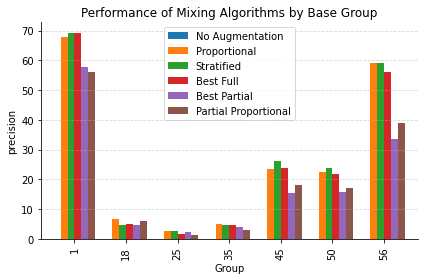

,No Augmentation,Proportional,Stratified,Best Full,Best Partial,Partial Proportional
1,0.0,67.710372,69.080235,69.275930,57.925636,55.968689
18,0.0,6.759318,4.653611,4.948410,4.632554,5.917035
25,0.0,2.630506,2.783442,1.753670,2.508157,1.407015
35,0.0,4.996915,4.565083,4.832408,3.907053,3.125643
45,0.0,23.625731,26.315789,23.859649,15.438596,18.011696
50,0.0,22.439661,24.005219,21.983040,15.916504,17.090672
56,0.0,59.164420,59.029650,56.064690,33.692722,38.814016


In [7]:
import pandas as pd

def percent_change(old, new):
    return 100 * (new - old) / old

mixing_algs = ["No Augmentation", "Proportional", "Stratified", "Best Full", "Best Partial", "Partial Proportional"]
assert np.all([len(mixing_results_by_group[label]["test metrics"]) == len(mixing_algs) for label in mixing_results_by_group])

metric_name = "precision"

dataframe_dict = {}
labels = list(mixing_results_by_group.keys())
for mixing_alg_idx, mixing_alg_name in enumerate(mixing_algs):
    mixing_alg_values_by_label = [
        percent_change(
            mixing_results_by_group[label]["test metrics"][0][metric_name],
            mixing_results_by_group[label]["test metrics"][mixing_alg_idx][metric_name]
        )
        for label in labels
    ]
    
    dataframe_dict[mixing_alg_name] = mixing_alg_values_by_label

metric_values_df = pd.DataFrame(dataframe_dict, index=labels)



ax = metric_values_df.plot(
    kind="bar",
    figsize=(6, 4),
    width=0.8
)

ax.set_xlabel("Group")
ax.set_ylabel(metric_name)
ax.set_title("Performance of Mixing Algorithms by Base Group")
# ax.legend(title="Mixing Algorithm")

ax.grid(axis="y", linestyle="--", alpha=0.5)
# ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

metric_values_df